# load_results

Final report-results notebook. It loads the frozen full-run outputs, reconstructs the validated main-body results without refitting any model, produces the report figures, and keeps appendix-only summaries in a separate final section.


## Final result loading and inference helpers


In [35]:
# IMPORTANT - this chooes the saved run version for which we load results
# the version set below is the final full-code run for the submitted MSc report
RUN_TO_LOAD = "20260827_054747"

In [36]:
import os
os.environ["GNAR_RUN_VERSION"] = RUN_TO_LOAD

import importlib, shared_utils
importlib.reload(shared_utils)
from shared_utils import *

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from statsmodels.stats.multitest import multipletests

FIG_DIR = HOME / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [37]:
def newey_west_bandwidth(n, horizon=1):
    """Return the automatic Bartlett-HAC bandwidth for a forecast loss differential."""
    if n < 3:
        raise ValueError("At least three loss observations are required.")
    if not isinstance(horizon, (int, np.integer)) or horizon < 1:
        raise ValueError("horizon must be a positive integer.")
    automatic = int(np.floor(4 * (n / 100) ** (2 / 9)))
    return min(n - 1, max(horizon - 1, automatic))

def newey_west_se(x, bandwidth):
    """Newey-West/Bartlett standard error for the mean of a monthly loss series."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    if not 0 <= bandwidth < n:
        raise ValueError("bandwidth must lie between 0 and n-1.")
    z = x - x.mean()
    lrv = np.sum(z**2) / n
    for lag in range(1, bandwidth + 1):
        gamma = np.sum(z[lag:] * z[:-lag]) / n
        lrv += 2.0 * (1.0 - lag / (bandwidth + 1.0)) * gamma
    return float(np.sqrt(max(lrv, 0.0) / n))

def dm_hac_test(loss_a, loss_b, horizon=1):
    """DM test with Bartlett-HAC variance and the HLN small-sample correction."""
    loss_a = np.asarray(loss_a, dtype=float)
    loss_b = np.asarray(loss_b, dtype=float)
    if loss_a.ndim != 1 or loss_a.shape != loss_b.shape:
        raise ValueError("Paired loss series must be one-dimensional and equal length.")

    diff = loss_a - loss_b
    n = len(diff)
    bandwidth = newey_west_bandwidth(n, horizon)
    se_hac = newey_west_se(diff, bandwidth)

    correction_sq = (n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n
    if se_hac <= 0 or correction_sq <= 0:
        raise FloatingPointError("Invalid variance or HLN correction in DM comparison.")

    correction = np.sqrt(correction_sq)
    se = se_hac / correction
    mean = float(diff.mean())
    stat = mean / se
    p_value = float(2 * stats.t.sf(abs(stat), df=n - 1))
    critical = stats.t.ppf(0.975, df=n - 1)

    return {
        "n": n, "bandwidth": int(bandwidth), "mean": mean, "se": float(se),
        "stat": float(stat), "p": p_value,
        "lo95": float(mean - critical * se), "hi95": float(mean + critical * se),
    }

R = {
    "selection": load_result("nb0_selection"),
    "primary": load_result("nb1_primary_models"),
    "benchmarks": load_result("nb2_benchmarks"),
    "calibration": load_result("nb4_calibration"),
    "robustness": load_result("nb5_specification_robustness"),
    "factor_diagnostic": load_result("nb6_common_factor"),
    "network_robustness": load_result("nb7_network_robustness"),
    "ragnar": load_result("nb8_ragnar_search"),
    "common_component": load_result("nb9_common_component"),
    "simulation": load_result("nb10_simulation"),
    "rolling": load_result("nb11_rolling_origins"),
}
selection = R["selection"]["selection"]
assert int(selection["p"]) == 38
assert selection["network"] == "geographic"
assert int(selection["k"]) == 2
assert int(selection["max_stage"]) == 2
print("loaded final result set")

result_versions = []
for key, obj in R.items():
    cfg = obj.get("config", {})
    if isinstance(cfg, dict) and cfg.get("run_version") is not None:
        result_versions.append((key, cfg["run_version"]))
if result_versions:
    versions = {version for _, version in result_versions}
    if len(versions) != 1:
        raise RuntimeError(f"Result objects span multiple run versions: {result_versions}")


loaded final result set


# Main-body results

The cells in this section reproduce only quantities used directly in the main report. Appendix-only diagnostics and robustness tables are collected at the end of the notebook.


## Primary forecast scoreboard


In [38]:
core_bundles = R["primary"]["forecast_bundles"]
benchmark_bundles = {
    k: v for k, v in R["benchmarks"]["forecast_bundles"].items() if v is not None
}
bundle_map = {**core_bundles, **benchmark_bundles}

reference_name = core_bundles["selected_sv"]
reference = load_forecasts(reference_name)

reference_loss = crps_series(
    reference["y_true"], reference["mean"], reference["var"]
)

rows = []
compatible = {}

# Compare every compatible forecast with the selected BGNAR-SV on identical targets.
for model, bundle in bundle_map.items():
    try:
        fc = load_forecasts(bundle)
    except FileNotFoundError:
        continue

    if "dates" not in fc or "dates" not in reference:
        raise ValueError(f"{bundle}: forecast dates are required.")

    same_dates = pd.DatetimeIndex(fc["dates"]).equals(
        pd.DatetimeIndex(reference["dates"])
    )
    same_shape = fc["y_true"].shape == reference["y_true"].shape
    same_target = same_shape and np.array_equal(
        fc["y_true"], reference["y_true"]
    )

    if not (same_dates and same_target):
        print(f"excluded from common scoreboard: {model}")
        continue

    compatible[model] = fc
    score = score_forecasts(
        fc["y_true"], fc["mean"], fc["var"], fc["dates"]
    )
    model_loss = crps_series(
        fc["y_true"], fc["mean"], fc["var"]
    )

    if model == "selected_sv":
        dm_stat, dm_p, dm_bandwidth = np.nan, np.nan, np.nan
    else:
        dm = dm_hac_test(model_loss, reference_loss, horizon=1)
        dm_stat, dm_p, dm_bandwidth = dm["stat"], dm["p"], dm["bandwidth"]

    rows.append({
        "model": model,
        **score,
        "DM_stat_vs_selected": dm_stat,
        "DM_p_vs_selected": dm_p,
        "DM_bandwidth_vs_selected": dm_bandwidth,
    })

scoreboard = pd.DataFrame(rows).sort_values("CRPS")

print(
    scoreboard[
        [
            "model", "CRPS", "RMSE", "MAE",
            "Coverage_95", "Width", "DM_p_vs_selected",
        ]
    ].round(6).to_string(index=False)
)


            model     CRPS     RMSE      MAE  Coverage_95    Width  DM_p_vs_selected
       ar38_garch 0.231043 0.452323 0.312733     0.875959 1.320820          0.276525
  country_ar38_sv 0.236950 0.460455 0.318496     0.858909 1.221689          0.672810
uniform_stage1_sv 0.240032 0.472896 0.323622     0.907928 1.386411          0.408052
 import_stage2_sv 0.240402 0.473214 0.323796     0.905797 1.386819          0.938835
      selected_sv 0.240569 0.472838 0.324720     0.904518 1.384965               NaN
 export_stage2_sv 0.240735 0.473739 0.323871     0.905797 1.379524          0.924594
    geo_stage1_sv 0.240988 0.473675 0.325577     0.905371 1.385470          0.448430
selected_constant 0.243041 0.470309 0.323717     0.884058 1.320733          0.011847
            ar_sv 0.245975 0.483076 0.332292     0.906223 1.406472          0.008521
        ar1_garch 0.275302 0.559377 0.377140     0.907502 1.712350          0.000301
   country_ar1_sv 0.279197 0.559074 0.377299     0.890878 1.57520

## Paired forecast comparisons


In [39]:
monthly = {
    key: np.asarray(value, dtype=float)
    for key, value in R["primary"]["monthly_crps"].items()
}
comparison_pairs = {
    "SV minus matched constant":
        ("selected_sv", "selected_constant"),
    "first-stage topology: geographic s1 minus uniform s1":
        ("geo_stage1_sv", "uniform_stage1_sv"),
    "second-stage increment: geographic s2 minus geographic s1":
        ("selected_sv", "geo_stage1_sv"),
    "generic cross-sectional increment: uniform s1 minus AR":
        ("uniform_stage1_sv", "ar_sv"),
    "geographic s2 minus export s2":
        ("selected_sv", "export_stage2_sv"),
    "geographic s2 minus import s2":
        ("selected_sv", "import_stage2_sv"),
    "overall model difference: geographic s2 minus uniform s1":
        ("selected_sv", "uniform_stage1_sv"),
}

# Primary one-step comparisons use the same HAC variance for the test and interval.
inference = {}
for label, (a, b) in comparison_pairs.items():
    loss_a, loss_b = monthly[a], monthly[b]
    result = dm_hac_test(loss_a, loss_b, horizon=1)
    inference[label] = {
        "sign_convention": "first-listed model CRPS minus second-listed model CRPS",
        **result,
    }

for label, result in inference.items():
    print(
        f"{label}: {result['mean']:+.6f} "
        f"[{result['lo95']:+.6f}, {result['hi95']:+.6f}], "
        f"HAC L={result['bandwidth']}, DM p={result['p']:.5f}"
    )

pc1 = R["common_component"]["pc1_adjusted"]
pc1_monthly = {
    key: np.asarray(value, dtype=float)
    for key, value in pc1["monthly_crps"].items()
}
pc1_inference = {}

# Repeat the same paired procedure on the PC1-adjusted response.
for label, meta in pc1["comparisons"].items():
    first = meta["first_model"]
    second = meta["second_model"]
    loss_first = pc1_monthly[first]
    loss_second = pc1_monthly[second]

    saved_diff = np.asarray(pc1["paired_monthly_losses"][label], dtype=float)
    np.testing.assert_allclose(
        loss_first - loss_second, saved_diff, rtol=0.0, atol=1e-12
    )

    result = dm_hac_test(loss_first, loss_second, horizon=1)
    pc1_inference[label] = {
        "sign_convention": (
            "first-listed PC1-adjusted model CRPS minus "
            "second-listed PC1-adjusted model CRPS"
        ),
        "first_model": first, "second_model": second,
        **result,
    }

print("\nPC1-adjusted paired comparisons")
for label, result in pc1_inference.items():
    print(
        f"{label}: {result['mean']:+.6f} "
        f"[{result['lo95']:+.6f}, {result['hi95']:+.6f}], "
        f"HAC L={result['bandwidth']}, DM p={result['p']:.5f}"
    )


SV minus matched constant: -0.002472 [-0.004385, -0.000559], HAC L=4, DM p=0.01185
first-stage topology: geographic s1 minus uniform s1: +0.000956 [-0.000396, +0.002308], HAC L=4, DM p=0.16379
second-stage increment: geographic s2 minus geographic s1: -0.000419 [-0.001509, +0.000672], HAC L=4, DM p=0.44843
generic cross-sectional increment: uniform s1 minus AR: -0.005943 [-0.009890, -0.001996], HAC L=4, DM p=0.00354
geographic s2 minus export s2: -0.000165 [-0.003623, +0.003292], HAC L=4, DM p=0.92459
geographic s2 minus import s2: +0.000167 [-0.004140, +0.004474], HAC L=4, DM p=0.93884
overall model difference: geographic s2 minus uniform s1: +0.000538 [-0.000746, +0.001821], HAC L=4, DM p=0.40805

PC1-adjusted paired comparisons
uniform_minus_ar: -0.002057 [-0.003919, -0.000194], HAC L=4, DM p=0.03081
geo_stage1_minus_uniform: +0.000331 [-0.000688, +0.001350], HAC L=4, DM p=0.52128
geo_stage2_minus_geo_stage1: -0.000751 [-0.002053, +0.000551], HAC L=4, DM p=0.25518
geo_stage2_minus_a

In [40]:

# Report-facing matched comparisons use positive gain to favour the first model.
component_order = [
    ("Geo. stage-2 BGNAR-SV", "Matched constant GNAR", "SV minus matched constant"),
    ("Uniform aggregate", "Shared AR(38)-SV", "generic cross-sectional increment: uniform s1 minus AR"),
    ("Geo. stage 1", "Uniform aggregate", "first-stage topology: geographic s1 minus uniform s1"),
    ("Geo. stage 2", "Geo. stage 1", "second-stage increment: geographic s2 minus geographic s1"),
    ("Geo. stage 2", "Uniform aggregate", "overall model difference: geographic s2 minus uniform s1"),
]
component_gains = pd.DataFrame([
    {
        "model": model,
        "comparator": comparator,
        "CRPS_gain": -inference[key]["mean"],
        "DM_p": inference[key]["p"],
    }
    for model, comparator, key in component_order
])

print("Report Table 3: paired CRPS gains")
display(component_gains.round({"CRPS_gain": 6, "DM_p": 5}))


Report Table 3: paired CRPS gains


,model,comparator,CRPS_gain,DM_p
0,Geo. stage-2 BGNAR-SV,Matched constant GNAR,0.002472,0.01185
1,Uniform aggregate,Shared AR(38)-SV,0.005943,0.00354
2,Geo. stage 1,Uniform aggregate,-0.000956,0.16379
3,Geo. stage 2,Geo. stage 1,0.000419,0.44843
4,Geo. stage 2,Uniform aggregate,-0.000538,0.40805


## Rolling-origin inference


The saved monthly loss series are reused here to recompute the corrected HAC--DM and Holm inference. Forecasts and CRPS values are not recomputed.


In [41]:
rolling_pairwise = pd.DataFrame(R["rolling"]["pairwise"]).copy()
rolling_losses = {
    key: np.asarray(value, dtype=float)
    for key, value in R["rolling"]["monthly_losses"].items()
}
rolling_pairs = {
    "uniform_s1_minus_ar": ("uniform_s1", "ar"),
    "geo_s1_minus_uniform": ("geo_s1", "uniform_s1"),
    "geo_s2_minus_geo_s1": ("geo_s2", "geo_s1"),
}

rolling_pairwise["hac_bandwidth"] = np.nan
rolling_pairwise["dm_ci_lo95"] = np.nan
rolling_pairwise["dm_ci_hi95"] = np.nan

for idx, row in rolling_pairwise.iterrows():
    first, second = rolling_pairs[row["comparison"]]
    horizon = int(row["horizon"])
    prefix = f"{row['treatment']}|{row['train_end']}|h{horizon}|"
    loss_first = rolling_losses[prefix + first]
    loss_second = rolling_losses[prefix + second]

    result = dm_hac_test(loss_first, loss_second, horizon=horizon)
    np.testing.assert_allclose(
        result["mean"], row["mean_loss_difference"], rtol=0.0, atol=1e-12
    )

    rolling_pairwise.at[idx, "dm_stat"] = result["stat"]
    rolling_pairwise.at[idx, "p"] = result["p"]
    rolling_pairwise.at[idx, "hac_bandwidth"] = result["bandwidth"]
    rolling_pairwise.at[idx, "dm_ci_lo95"] = result["lo95"]
    rolling_pairwise.at[idx, "dm_ci_hi95"] = result["hi95"]

# Preserve the original Holm families, using the HAC-based raw p-values.
rolling_pairwise["p_holm"] = np.nan
rolling_pairwise["reject_holm"] = False
for treatment in rolling_pairwise["treatment"].unique():
    for comparison in rolling_pairwise["comparison"].unique():
        mask = (
            (rolling_pairwise["treatment"] == treatment)
            & (rolling_pairwise["comparison"] == comparison)
        )
        reject, adjusted, _, _ = multipletests(
            rolling_pairwise.loc[mask, "p"], alpha=0.05, method="holm"
        )
        rolling_pairwise.loc[mask, "p_holm"] = adjusted
        rolling_pairwise.loc[mask, "reject_holm"] = reject


## Selection and main diagnostics


In [42]:

complete_lag = pd.DataFrame(R["selection"]["complete_lag_screen"])
geo_refine = pd.DataFrame(R["selection"]["geo_k2_lag_refinement"])
search_p38 = pd.DataFrame(R["selection"]["search_p38"])
stage_depth = pd.DataFrame(R["selection"]["stage_depth_diagnostic"])
network_grid = pd.DataFrame(R["network_robustness"]["raw_grid"])
rolling_models = pd.DataFrame(R["rolling"]["models"])

print("Selected specification")
display(pd.DataFrame([selection]))

print("Stage-depth validation diagnostic")
display(stage_depth.round(6))

print("Primary-model stability")
display(pd.DataFrame(R["primary"]["stability"]).T.round(6))

print("Selected-design collinearity")
display(pd.DataFrame([R["factor_diagnostic"]["selected_design"]]).round(6))


Selected specification


,selection_converged,p,network,k,max_stage,stage2_pairs,stages,validation_CRPS,validation_RMSE,candidate_count,validation_start,validation_end,validation_months,validation_cells
0,True,38,geographic,2,2,34,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",0.169161,0.304418,129,2013-01-01T00:00:00,2015-12-01T00:00:00,36,828


Stage-depth validation diagnostic


,max_stage,mean_coefficients,training_rows,design_rank,validation_CRPS,validation_RMSE,BIC,log_marginal_likelihood
0,1,76,5198,76,0.169400,0.304892,3488.582300,-2298.748471
1,2,114,5198,114,0.169161,0.304418,3738.798107,-2299.297285


Primary-model stability


,median,q95,max,stable_fraction,unstable_fraction,draws,runtime_sec
selected_sv,0.988936,0.993263,0.998636,1.00000,0.00000,4000.0,496.108181
selected_constant,0.990169,0.994303,0.998808,1.00000,0.00000,4000.0,488.511014
geo_stage1_sv,0.988126,0.992583,0.997036,1.00000,0.00000,4000.0,45.157283
ar_sv,0.986234,0.990030,0.994366,1.00000,0.00000,4000.0,0.668711
uniform_stage1_sv,0.987736,0.994197,1.002515,0.99725,0.00275,4000.0,44.832368
export_stage2_sv,0.998703,1.010617,1.023991,0.58100,0.41900,4000.0,195.082884
import_stage2_sv,1.010935,1.028061,1.053000,0.17575,0.82425,4000.0,262.735675


Selected-design collinearity


,stage1_vif,stage1_r2,stage2_vif,stage2_r2,stage1_stage2_corr,stage1_own_corr_mean,stage1_own_corr_min,stage1_own_corr_max,stage2_own_corr_mean,stage2_own_corr_min,stage2_own_corr_max
0,104.360103,0.990418,71.710909,0.986055,0.375555,0.624967,0.126815,0.915984,NaN,NaN,NaN


## PC1-adjusted comparison


In [43]:

pc1 = R["common_component"]["pc1_adjusted"]
pc1_score_table = pd.DataFrame([
    {
        "model": model,
        "CRPS": result["CRPS"],
        "RMSE": result["RMSE"],
        "MAE": result["MAE"],
        "Coverage_95": result["Coverage_95"],
        "Width": result["Width"],
    }
    for model, result in pc1["scores"].items()
])

pc1_dm_table = pd.DataFrame([
    {
        "comparison": label,
        "first_model": result["first_model"],
        "second_model": result["second_model"],
        "CRPS_gain_first_over_second": -result["mean"],
        "DM_p": result["p"],
    }
    for label, result in pc1_inference.items()
])

print("PC1-adjusted forecast scores")
display(pc1_score_table.round(6))

print("PC1-adjusted paired comparisons")
display(pc1_dm_table.round({"CRPS_gain_first_over_second": 6, "DM_p": 5}))

print("PC1 adjustment")
display(pd.DataFrame([{
    "training_months": pc1["pca"]["training_months"],
    "PC1_variance_share": pc1["pca"]["pc1_variance_share"],
}]).round(6))


PC1-adjusted forecast scores


,model,CRPS,RMSE,MAE,Coverage_95,Width
0,ar,0.222648,0.440259,0.300179,0.907928,1.293265
1,uniform,0.220591,0.436306,0.297525,0.910912,1.286644
2,geo_stage1,0.220922,0.436498,0.297446,0.910060,1.286272
3,geo_stage2,0.220171,0.435007,0.296351,0.908781,1.284758


PC1-adjusted paired comparisons


,comparison,first_model,second_model,CRPS_gain_first_over_second,DM_p
0,uniform_minus_ar,uniform,ar,0.002057,0.03081
1,geo_stage1_minus_uniform,geo_stage1,uniform,-0.000331,0.52128
2,geo_stage2_minus_geo_stage1,geo_stage2,geo_stage1,0.000751,0.25518
3,geo_stage2_minus_ar,geo_stage2,ar,0.002477,0.04293


PC1 adjustment


,training_months,PC1_variance_share
0,300,0.888292


# Report figures

The existing figure cells below are preserved verbatim from the validated final `load_results` notebook, including all plotting and stylistic choices.


In [44]:
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

inflation = pd.read_csv(INFLATION_CSV, index_col=0, parse_dates=True).sort_index()

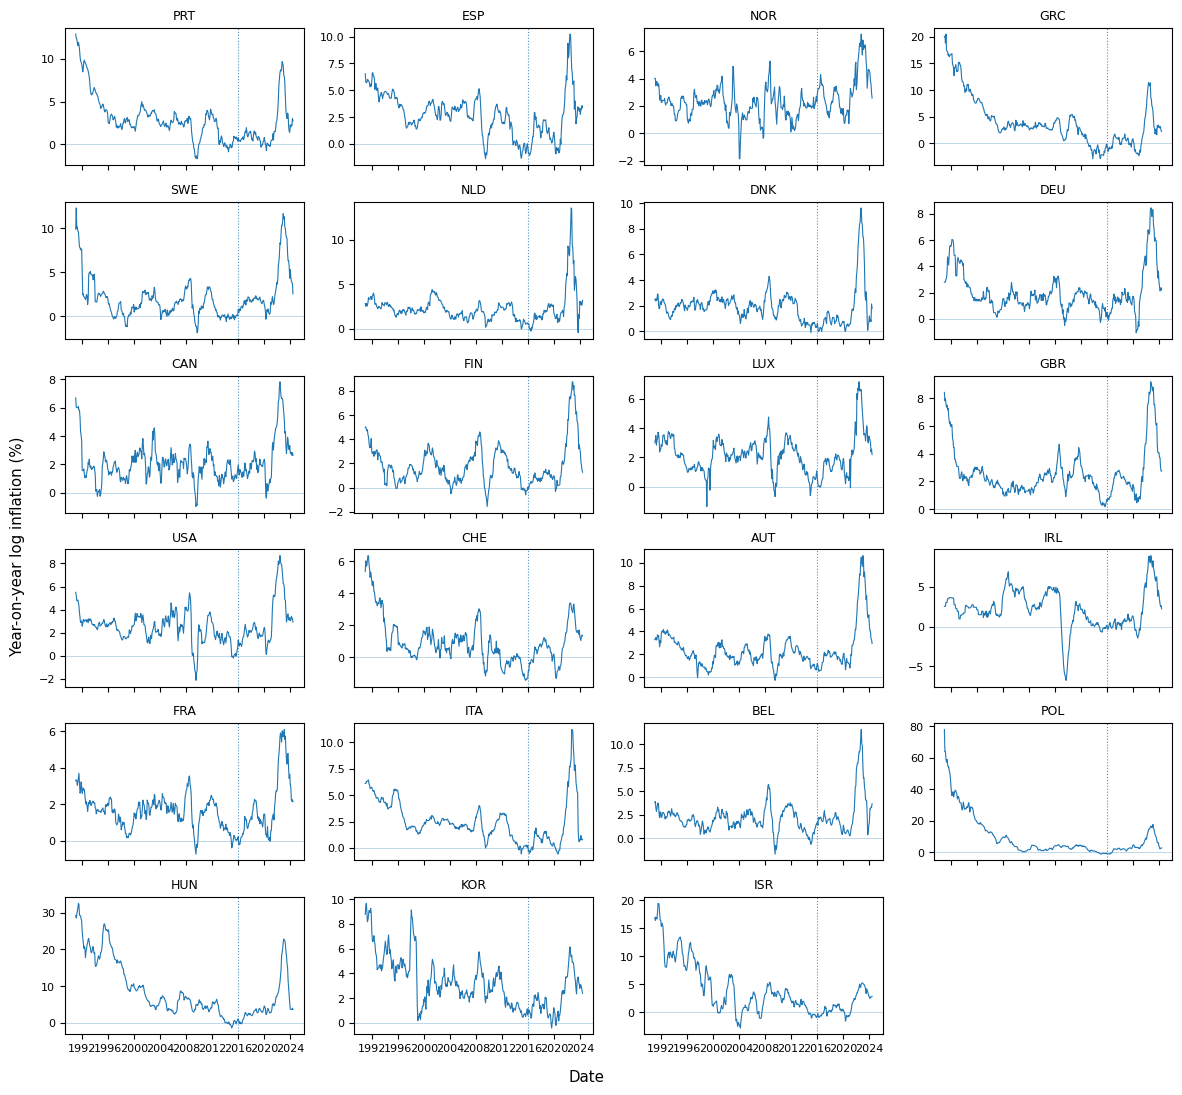

In [45]:
# All-country inflation small multiples.
fig, axes = plt.subplots(6, 4, figsize=(12, 11), sharex=True)
axes = axes.ravel()
for ax, country in zip(axes, inflation.columns):
    ax.plot(inflation.index, inflation[country], lw=0.8)
    ax.axvline(pd.Timestamp(SPLIT_DATE), ls=":", lw=0.8, alpha=0.8)
    ax.axhline(0, lw=0.5, alpha=0.4)
    ax.set_title(country)
for ax in axes[len(inflation.columns):]:
    ax.set_visible(False)
fig.supxlabel("Date")
fig.supylabel("Year-on-year log inflation (%)")
fig.tight_layout()
fig.savefig(FIG_DIR / "inflation_all_countries.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

In [46]:
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

LINEWIDTH = 1.35

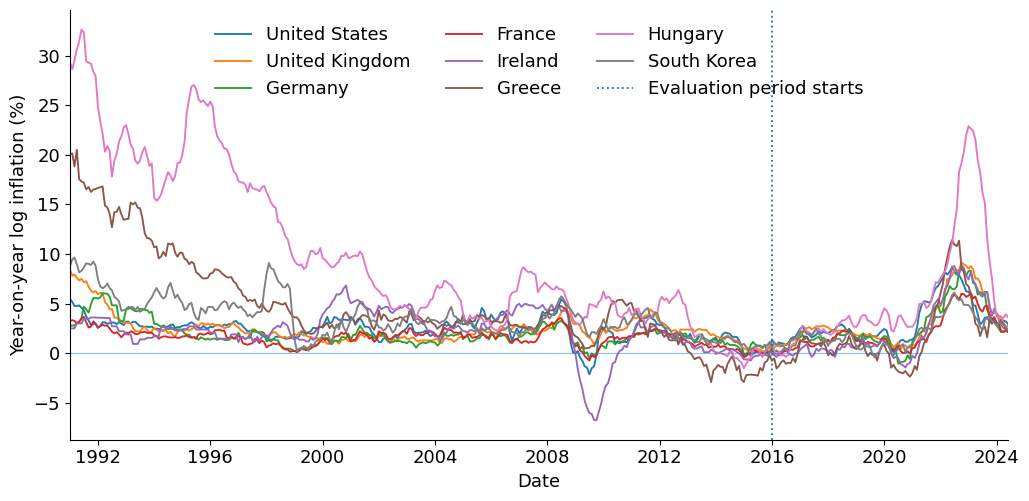

In [47]:
selected = {
    "USA": "United States",
    "GBR": "United Kingdom",
    "DEU": "Germany",
    "FRA": "France",
    "IRL": "Ireland",
    "GRC": "Greece",
    "HUN": "Hungary",
    "KOR": "South Korea"
}

fig, ax = plt.subplots(figsize=(10.5, 5.2))
for iso, label in selected.items():
    ax.plot(inflation.index, inflation[iso], linewidth=LINEWIDTH, label=label)

ax.axvline(pd.Timestamp(SPLIT_DATE), ls=":", lw=LINEWIDTH, label="Evaluation period starts")
ax.axhline(0, linewidth=0.9, alpha=0.45)
ax.set_xlim(inflation.index[0], inflation.index[-1])
ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year log inflation (%)")
ax.legend(frameon=False, ncol=3, loc="upper center")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "inflation_selected.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

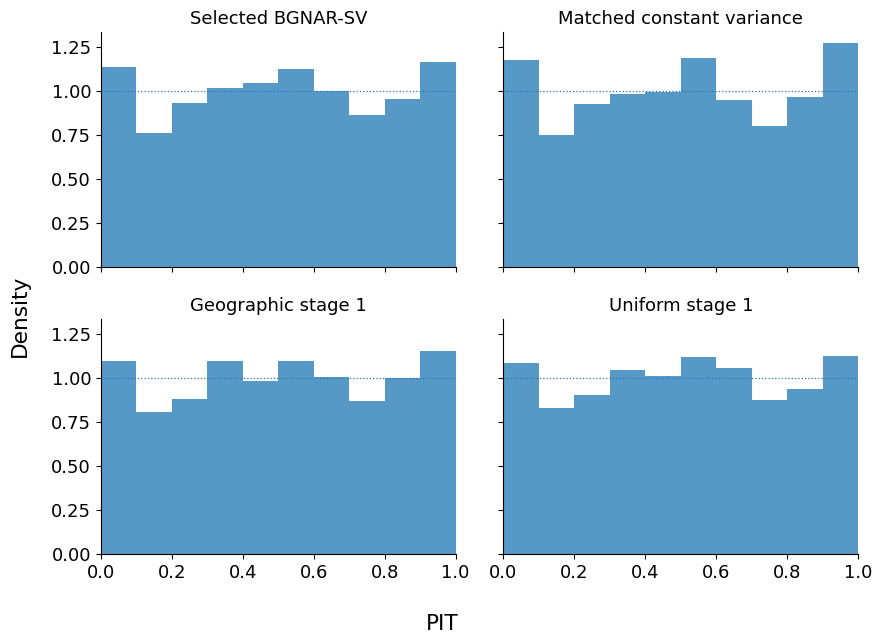

In [48]:
# Pooled PIT diagnostics for the principal matched forecast models.
pit_results = R["calibration"]["pit_values"]

pit_models = [
    ("selected_sv", "Selected BGNAR-SV"),
    ("selected_constant", "Matched constant variance"),
    ("geo_stage1_sv", "Geographic stage 1"),
    ("uniform_stage1_sv", "Uniform stage 1"),
]
pit_models = [
    (key, label) for key, label in pit_models
    if key in pit_results
]

fig, axes = plt.subplots(
    2, 2, figsize=(9, 6.5), sharex=True, sharey=True
)
axes = np.asarray(axes).ravel()
bins = np.linspace(0, 1, 11)

for ax, (key, label) in zip(axes, pit_models):
    pooled = np.concatenate([
        np.asarray(values, dtype=float)
        for values in pit_results[key].values()
    ])
    ax.hist(pooled, bins=bins, density=True, alpha=0.75)
    ax.axhline(1.0, ls=":", lw=0.9)
    ax.set_title(label)
    ax.set_xlim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(pit_models):]:
    ax.set_visible(False)

fig.supxlabel("PIT")
fig.supylabel("Density")
fig.tight_layout()
fig.savefig(FIG_DIR / "pit_histograms.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

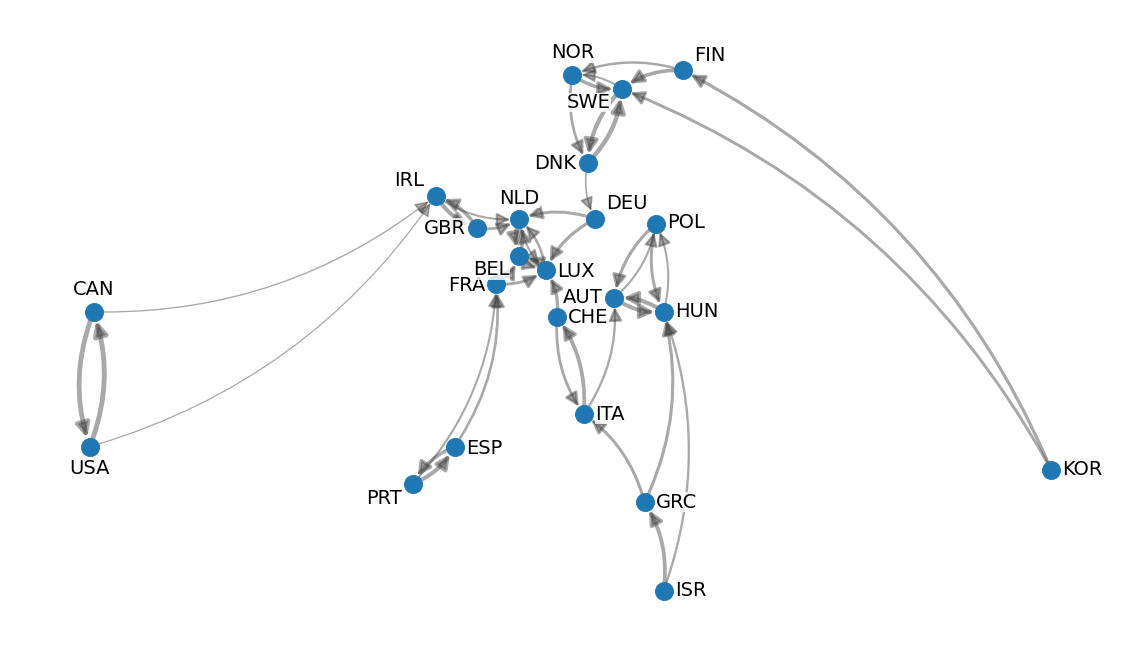

In [49]:
# Schematic coordinates used only for plotting this figure.
# They preserve broad geography but deliberately spread the European cluster.
plot_coords = {
    "CAN": (-11.0,  2.8),
    "USA": (-11.1, -0.1),

    "PRT": ( -2.6, -0.9),
    "ESP": ( -1.5, -0.1),
    "IRL": ( -2.0,  5.3),
    "GBR": ( -0.9,  4.6),
    "FRA": ( -0.4,  3.4),
    "BEL": (  0.2,  4.0),
    "NLD": (  0.2,  4.8),
    "LUX": (  0.9,  3.7),
    "CHE": (  1.2,  2.7),
    "DEU": (  2.2,  4.8),
    "DNK": (  2.0,  6.0),
    "NOR": (  1.6,  7.9),
    "SWE": (  2.9,  7.6),
    "FIN": (  4.5,  8.0),
    "POL": (  3.8,  4.7),
    "AUT": (  2.7,  3.1),
    "HUN": (  4.0,  2.8),
    "ITA": (  1.9,  0.6),
    "GRC": (  3.5, -1.3),

    "ISR": (  4.0, -3.2),
    "KOR": ( 14.2, -0.6),
}

# Selected geographic k=2 first-stage network.
data = load_data(network="geographic")
countries = data["countries"]
W_geo_k2 = knn_sparsify(data["networks"]["geographic"], 2)
assert np.all((W_geo_k2 > 0).sum(axis=1) == 2)

G = nx.DiGraph()
G.add_nodes_from(countries)
for i, src in enumerate(countries):
    for j, dst in enumerate(countries):
        if W_geo_k2[i, j] > 0:
            G.add_edge(src, dst, weight=float(W_geo_k2[i, j]))

# Draw weaker links first so the strongest relationships remain visible.
edges = sorted(G.edges(data=True), key=lambda edge: edge[2]["weight"])
edgelist = [(u, v) for u, v, _ in edges]
edge_weights = np.array([d["weight"] for _, _, d in edges])
scaled = (edge_weights - edge_weights.min()) / max(np.ptp(edge_weights), 1e-12)

# Thicker and more visible arrows.
edge_widths = 0.9 + 2.6 * scaled

# Label offsets, tuned for the schematic layout.
label_positions = {
    "CAN": (0, 9, "center", "bottom"),
    "USA": (0, -9, "center", "top"),

    "PRT": (-8, -4, "right", "top"),
    "ESP": (8, -1, "left", "center"),
    "IRL": (-8, 4, "right", "bottom"),
    "GBR": (-8, 0, "right", "center"),
    "FRA": (-8, -1, "right", "center"),
    "BEL": (-7, -3, "right", "top"),
    "NLD": (0, 8, "center", "bottom"),
    "LUX": (8, -1, "left", "center"),
    "CHE": (8, -1, "left", "center"),
    "DEU": (8, 4, "left", "bottom"),
    "DNK": (-8, 0, "right", "center"),
    "NOR": (0, 9, "center", "bottom"),
    "SWE": (-8, -3, "right", "top"),
    "FIN": (8, 4, "left", "bottom"),
    "POL": (8, 1, "left", "center"),
    "AUT": (-8, 0, "right", "center"),
    "HUN": (8, 0, "left", "center"),
    "ITA": (8, 0, "left", "center"),
    "GRC": (8, 0, "left", "center"),

    "ISR": (8, 0, "left", "center"),
    "KOR": (8, 0, "left", "center"),
}

NODE_SIZE = 170
LABEL_FONTSIZE = 14
ARROW_SIZE = 20

fig, ax = plt.subplots(figsize=(11.6, 6.8))

nx.draw_networkx_edges(
    G,
    plot_coords,
    ax=ax,
    edgelist=edgelist,
    width=edge_widths,
    alpha=0.45,
    edge_color="0.25",
    arrows=True,
    arrowsize=ARROW_SIZE,
    node_size=NODE_SIZE,
    min_source_margin=4,
    min_target_margin=6,
    connectionstyle="arc3,rad=0.18",
)

nx.draw_networkx_nodes(
    G,
    plot_coords,
    ax=ax,
    node_size=NODE_SIZE,
    linewidths=0.6,
)

for country, (x, y) in plot_coords.items():
    dx, dy, ha, va = label_positions[country]
    ax.annotate(
        country,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        fontsize=LABEL_FONTSIZE,
        zorder=3,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.82, pad=0.30),
    )

ax.margins(x=0.03, y=0.06)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIG_DIR / "geographic_network_k2.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

In [50]:
LINEWIDTH = 1.1

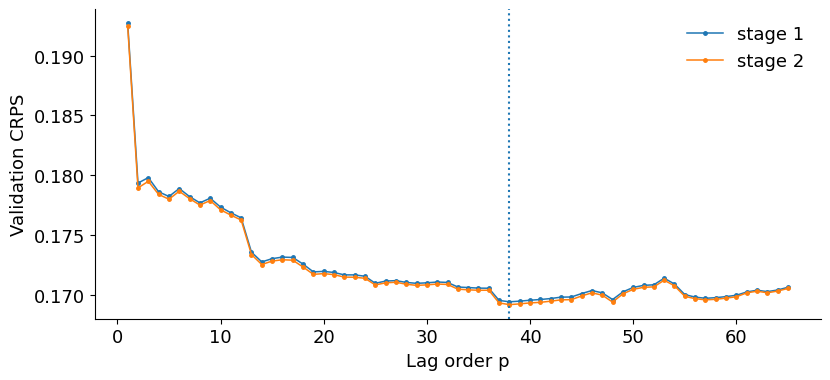

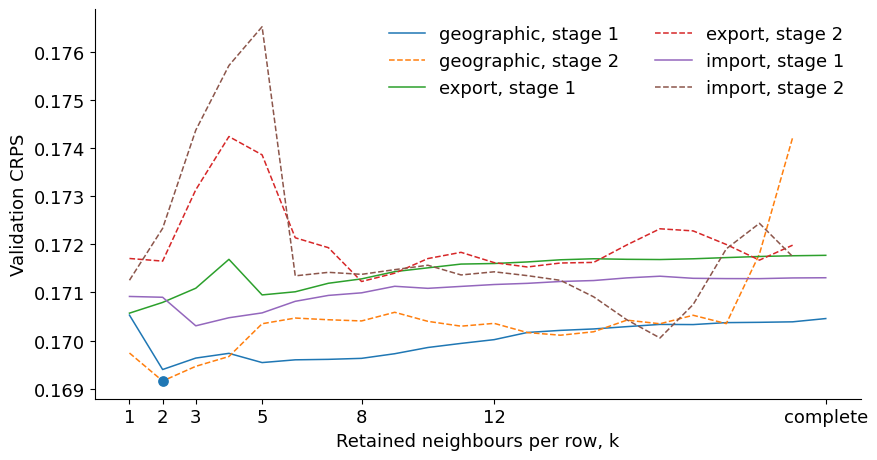

In [51]:
# Pre-evaluation lag/stage selection.
fig, ax = plt.subplots(figsize=(8.5, 4.0))
for stage in [1, 2]:
    sub = geo_refine[geo_refine["max_stage"] == stage].sort_values("p")
    ax.plot(sub["p"], sub["validation_CRPS"], marker="o", ms=2.5, lw=LINEWIDTH,
            label=f"stage {stage}")
ax.axvline(38, ls=":", lw=1.5)
ax.set_xlabel("Lag order p")
ax.set_ylabel("Validation CRPS")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "selection_lag_stage_crps.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# Pre-evaluation network/density selection at p=38.
fig, ax = plt.subplots(figsize=(9, 4.8))
sel_plot = search_p38.copy()
sel_plot["k_num"] = sel_plot["k"].map(
    lambda x: 22 if str(x) == "complete" else int(x)
)

for network in ["geographic", "export", "import"]:
    for stage, ls in [(1, "-"), (2, "--")]:
        sub = sel_plot[
            (sel_plot["network"] == network)
            & (sel_plot["max_stage"] == stage)
        ].sort_values("k_num")
        if len(sub):
            ax.plot(
                sub["k_num"], sub["validation_CRPS"],
                ls=ls, lw=LINEWIDTH, label=f"{network}, stage {stage}"
            )

winner = search_p38.loc[search_p38["validation_CRPS"].idxmin()]
winner_x = 22 if str(winner["k"]) == "complete" else int(winner["k"])
ax.scatter([winner_x], [winner["validation_CRPS"]], s=45, zorder=4)

ax.set_xlabel("Retained neighbours per row, k")
ax.set_ylabel("Validation CRPS")
ax.set_xticks(
    [1, 2, 3, 5, 8, 12, 22],
    ["1", "2", "3", "5", "8", "12", "complete"],
)
ax.legend(frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "selection_network_density.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

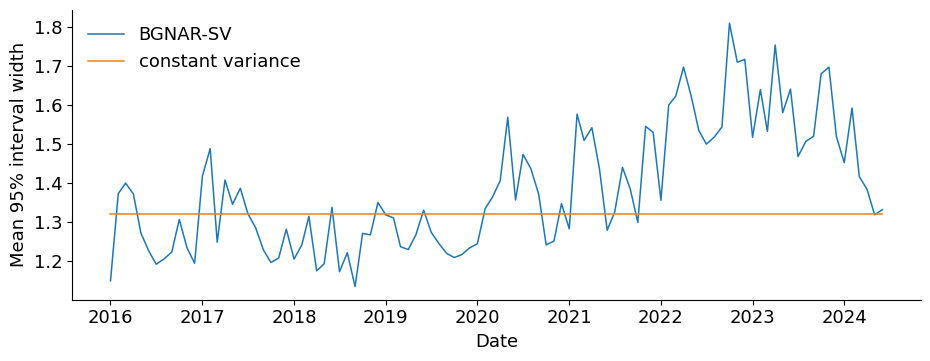

In [52]:
# Predictive interval adaptation.
fc_sv = load_forecasts(core_bundles["selected_sv"])
fc_const = load_forecasts(core_bundles["selected_constant"])
assert pd.DatetimeIndex(fc_sv["dates"]).equals(pd.DatetimeIndex(fc_const["dates"]))
np.testing.assert_array_equal(fc_sv["y_true"], fc_const["y_true"])

width_sv = 2 * 1.96 * np.sqrt(fc_sv["var"]).mean(axis=1)
width_const = 2 * 1.96 * np.sqrt(fc_const["var"]).mean(axis=1)
fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(fc_sv["dates"], width_sv, lw=LINEWIDTH, label="BGNAR-SV")
ax.plot(fc_const["dates"], width_const, lw=LINEWIDTH, label="constant variance")
ax.set_xlabel("Date")
ax.set_ylabel("Mean 95% interval width")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "sv_interval_width.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

In [53]:
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

LINEWIDTH = 1.75

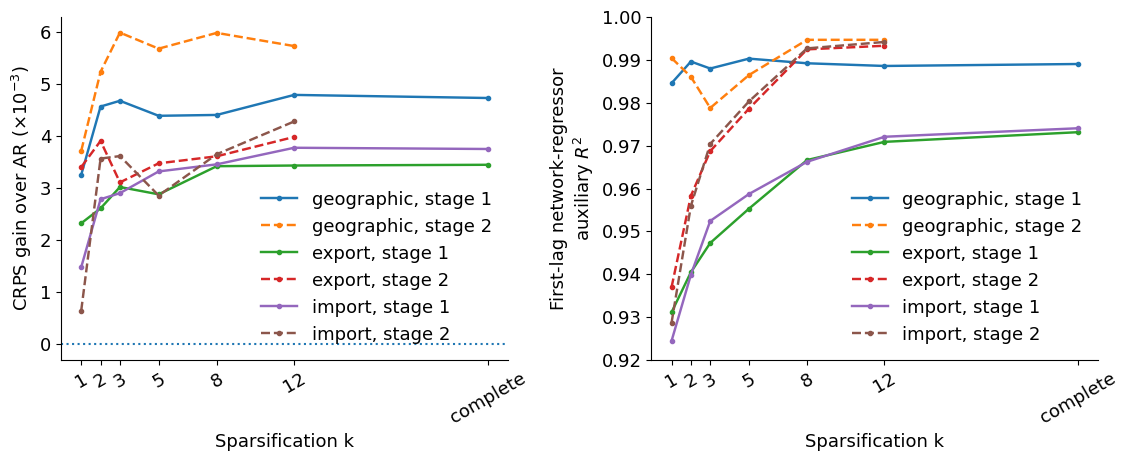

In [63]:
# Test-period sparsity and collinearity.
display_k = {"1", "2", "3", "5", "8", "12", "complete"}
sp = network_grid[network_grid["k"].astype(str).isin(display_k)].copy()
sp["x"] = sp["k"].map(lambda x: 22 if str(x) == "complete" else int(x))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for network in ["geographic", "export", "import"]:
    for stage, ls in [(1, "-"), (2, "--")]:
        sub = sp[(sp["network"] == network) & (sp["max_stage"] == stage)].sort_values("x")
        if not len(sub):
            continue
        axes[0].plot(
            sub["x"], 1e3 * sub["gain_vs_AR"], ls=ls, lw=LINEWIDTH, marker="o", ms=3,
            label=f"{network}, stage {stage}"
        )
        r2_col = "stage1_R2" if stage == 1 else "stage2_R2"
        axes[1].plot(
            sub["x"], sub[r2_col], ls=ls, lw=LINEWIDTH, marker="o", ms=3,
            label=f"{network}, stage {stage}"
        )

axes[0].axhline(0, ls=":", lw=1.5)
axes[0].set_ylabel(r"CRPS gain over AR ($\times 10^{-3}$)")
axes[1].set_ylabel("First-lag network-regressor\nauxiliary $R^2$")
axes[1].set_ylim(0.92, 1.0)
for ax in axes:
    ax.set_xlabel("Sparsification k")
    ax.set_xticks([1, 2, 3, 5, 8, 12, 22], ["1", "2", "3", "5", "8", "12", "complete"])
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "sparsity_and_vif.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

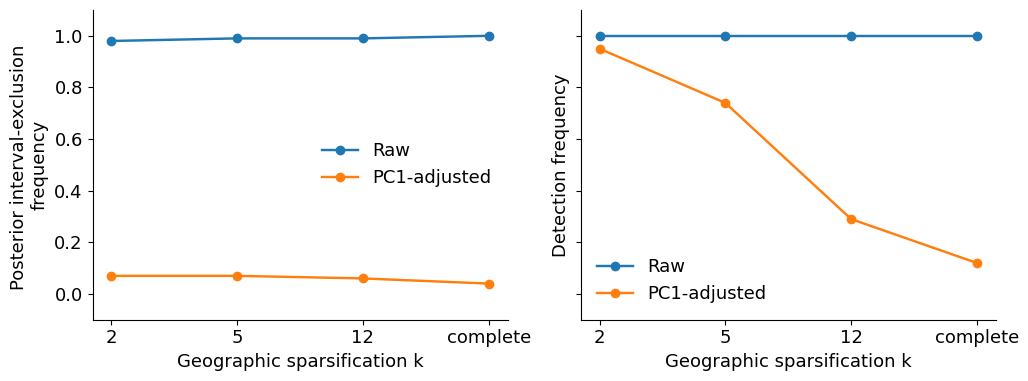

In [55]:
# Simulation geographic-densification ladder.
density = pd.DataFrame(R["simulation"]["density_ladder"])
k_order = ["2", "5", "12", "complete"]
spec_order = ["raw", "pc1_adjusted"]
spec_labels = R["simulation"].get(
    "spec_labels",
    {"raw": "Raw", "pc1_adjusted": "PC1-adjusted"},
)

unexpected = set(density["spec"]) - set(spec_order)
if unexpected:
    raise ValueError(f"Unexpected simulation specifications: {sorted(unexpected)}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True)
for ax, dgp, ylabel in [
    (axes[0], "DGP2", "Posterior interval-exclusion \nfrequency"),
    (axes[1], "DGP4", "Detection frequency"),
]:
    sub = density[density["dgp_base"] == dgp].copy()
    for spec in spec_order:
        ss = sub[sub["spec"] == spec].copy()
        ss["order"] = ss["k"].map({k: i for i, k in enumerate(k_order)})
        ss = ss.sort_values("order")
        if ss["k"].tolist() != k_order:
            raise ValueError(f"Unexpected k sequence for {dgp}, {spec}: {ss['k'].tolist()}")
        ax.plot(range(len(ss)), ss["rej_rate"], marker="o", label=spec_labels[spec], lw=LINEWIDTH)

    ax.set_xticks(range(len(k_order)), k_order)
    ax.set_xlabel("Geographic sparsification k")
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.1, 1.1)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "simulation_density.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

/var/folders/d5/bt4mpp9n3gngv4q0rms4ylwm0000gn/T/ipykernel_19575/2198500163.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


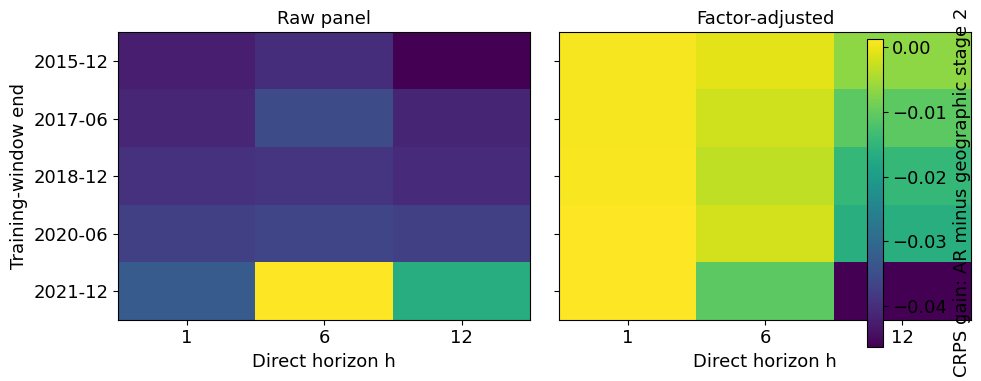

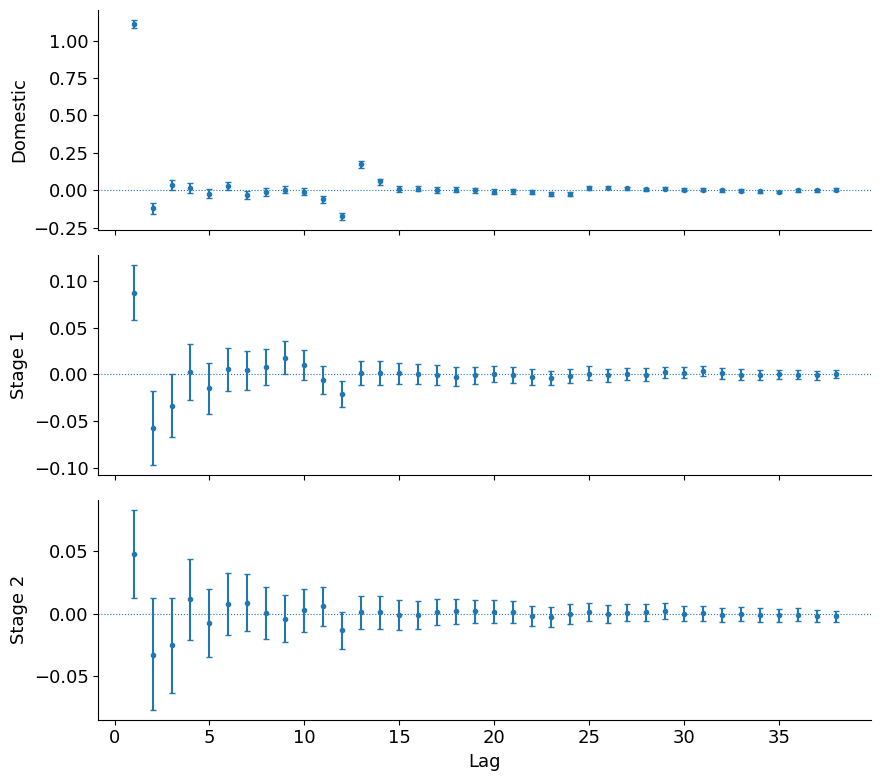

figures written to /Users/patrickgunn/Documents/Unis/Imperial College/Research Proj/figures


In [56]:
# Rolling-origin overall selected-model gain over AR.
roll = rolling_models.copy()
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, treatment in zip(axes, ["raw", "factor_adjusted"]):
    sub = roll[roll["treatment"] == treatment]
    ar = sub[sub["model"] == "ar"].pivot(index="train_end", columns="horizon", values="CRPS")
    geo = sub[sub["model"] == "geo_s2"].pivot(index="train_end", columns="horizon", values="CRPS")
    gain = (ar - geo).reindex(columns=[1,6,12])
    im = ax.imshow(gain.to_numpy(), aspect="auto")
    ax.set_xticks(range(3), ["1","6","12"])
    ax.set_yticks(range(len(gain.index)), gain.index)
    ax.set_xlabel("Direct horizon h")
    ax.set_title("Raw panel" if treatment == "raw" else "Factor-adjusted")
axes[0].set_ylabel("Training-window end")
cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.03)
cbar.set_label("CRPS gain: AR minus geographic stage 2")
fig.tight_layout()
fig.savefig(FIG_DIR / "rolling_gain_heatmap.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

# Selected-model lag profiles.
coef = pd.DataFrame(R["primary"]["coefficient_summary_selected"])
def lag_number(term):
    return int(term.split("lag", 1)[1].split("_", 1)[0])

profiles = [
    ("Domestic", coef[coef["term"].str.startswith("own_")]),
    ("Stage 1", coef[coef["term"].str.endswith("_stage1")]),
    ("Stage 2", coef[coef["term"].str.endswith("_stage2")]),
]
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for ax, (label, sub) in zip(axes, profiles):
    sub = sub.copy()
    sub["lag"] = sub["term"].map(lag_number)
    sub = sub.sort_values("lag")
    ax.errorbar(
        sub["lag"], sub["mean"],
        yerr=[sub["mean"]-sub["lo95"], sub["hi95"]-sub["mean"]],
        fmt="o", ms=3, capsize=2,
    )
    ax.axhline(0, ls=":", lw=0.8)
    ax.set_ylabel(label)
    ax.spines[["top","right"]].set_visible(False)
axes[-1].set_xlabel("Lag")
fig.tight_layout()
fig.savefig(FIG_DIR / "p38_lag_coefficients.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"figures written to {FIG_DIR}")

## Appendix simulation network figure

This reconstructs the deterministic four-community synthetic graph used by the simulation from the saved graph-generation settings (including a fixed seed). The density is checked against the saved simulation result before plotting.


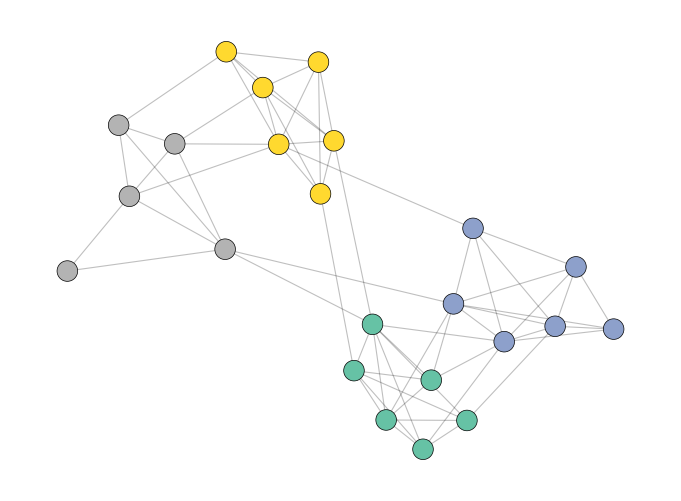

Synthetic block graph: density=0.25296, edges=64


In [57]:

def simulation_block_weights(n, n_blocks=4, proposal_p_in=0.7, proposal_p_out=0.05, seed=0):
    """Reconstruct the symmetric four-community simulation graph."""
    rng = np.random.default_rng(seed)
    block = np.arange(n) % n_blocks
    adjacency = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            p = proposal_p_in if block[i] == block[j] else proposal_p_out
            adjacency[i, j] = rng.random() < p
    adjacency = ((adjacency + adjacency.T) > 0).astype(float)
    np.fill_diagonal(adjacency, 0.0)
    if np.any(adjacency.sum(axis=1) == 0):
        raise RuntimeError("Synthetic block graph contains an isolated node.")
    return adjacency / adjacency.sum(axis=1, keepdims=True), block

sim = R["simulation"]
proposal = sim["block_graph_proposal_probabilities"]
W_block, block_membership = simulation_block_weights(
    int(sim["N"]), proposal_p_in=float(proposal["within"]),
    proposal_p_out=float(proposal["between"]), seed=0,
)
block_adjacency = W_block > 0
block_density = block_adjacency.sum() / (int(sim["N"]) * (int(sim["N"]) - 1))
np.testing.assert_allclose(block_density, float(sim["block_density"]), rtol=0.0, atol=1e-12)

G_block = nx.Graph()
G_block.add_nodes_from(range(int(sim["N"])))
for i in range(int(sim["N"])):
    for j in range(i + 1, int(sim["N"])):
        if block_adjacency[i, j]:
            G_block.add_edge(i, j)

pos_block = nx.spring_layout(G_block, seed=7)
fig, ax = plt.subplots(figsize=(7.0, 5.2))
nx.draw_networkx_edges(G_block, pos_block, ax=ax, alpha=0.25, width=0.8)
nx.draw_networkx_nodes(
    G_block, pos_block, ax=ax, node_size=220,
    node_color=block_membership, cmap=plt.cm.Set2,
    edgecolors="black", linewidths=0.5,
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIG_DIR / "simulation_block_network.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Synthetic block graph: density={block_density:.5f}, edges={G_block.number_of_edges()}")


# Supplementary / appendix results

These cells collect compact report-facing summaries for the appendices only. They read saved outputs from the final full run and do not refit or rescore any model.


## MCMC diagnostics

For country-by-country models, diagnostics are aggregated conservatively: divergences are summed, while the worst retained value is reported for $\hat R$, ESS and BFMI.


In [58]:

def aggregate_mcmc_diagnostics(rows):
    """Aggregate country-level MCMC diagnostics to one conservative summary row."""
    frame = pd.DataFrame(rows)
    return {
        "fits": int(len(frame)),
        "divergences": int(frame["divergences"].sum()),
        "max_rhat": float(frame["max_rhat"].max()),
        "min_ess_bulk": float(frame["min_ess_bulk"].min()),
        "min_ess_tail": float(frame["min_ess_tail"].min()),
        "min_bfmi": float(frame["min_bfmi"].min()),
    }

def single_mcmc_diagnostics(diag):
    """Put one saved MCMC diagnostic dictionary in the appendix-table format."""
    return {
        "fits": 1,
        "divergences": int(diag["divergences"]),
        "max_rhat": float(diag["max_rhat"]),
        "min_ess_bulk": float(diag["min_ess_bulk"]),
        "min_ess_tail": float(diag["min_ess_tail"]),
        "min_bfmi": float(diag["min_bfmi"]),
    }

mcmc_rows = []
primary_labels = {
    "selected_sv": "Geographic stage-2 BGNAR-SV",
    "selected_constant": "Matched constant GNAR",
    "geo_stage1_sv": "Geographic stage-1 BGNAR-SV",
    "ar_sv": "Shared AR(38)-SV",
    "uniform_stage1_sv": "Uniform aggregate BGNAR-SV",
    "export_stage2_sv": "Export stage-2 BGNAR-SV",
    "import_stage2_sv": "Import stage-2 BGNAR-SV",
}
for key, label in primary_labels.items():
    mcmc_rows.append({"model": label, **single_mcmc_diagnostics(R["primary"]["diagnostics"][key])})

pc1_labels = {
    "ar": "PC1-adjusted AR(38)",
    "uniform": "PC1-adjusted uniform",
    "geo_stage1": "PC1-adjusted geographic stage 1",
    "geo_stage2": "PC1-adjusted geographic stage 2",
}
for key, label in pc1_labels.items():
    mcmc_rows.append({"model": label, **single_mcmc_diagnostics(pc1["diagnostics"][key])})

for p in [1, 38]:
    diag = aggregate_mcmc_diagnostics(R["benchmarks"]["country_ar_sv"][str(p)]["diagnostics"])
    mcmc_rows.append({"model": f"Country AR({p})-SV", **diag})

mcmc_rows.append({"model": "BVAR(1)", **single_mcmc_diagnostics(R["benchmarks"]["bvar_diagnostics"])})
mcmc_rows.append({"model": "UCSV", **aggregate_mcmc_diagnostics(R["benchmarks"]["ucsv"]["diagnostics"])})

mcmc_appendix = pd.DataFrame(mcmc_rows)
retained_per_fit = int(NUTS_KW["draws"]) * int(NUTS_KW["chains"])
mcmc_appendix["retained_transitions"] = mcmc_appendix["fits"] * retained_per_fit
mcmc_appendix["divergence_pct"] = 100 * mcmc_appendix["divergences"] / mcmc_appendix["retained_transitions"]

print("Appendix: MCMC diagnostics")
display(mcmc_appendix.round({
    "max_rhat": 4, "min_ess_bulk": 0, "min_ess_tail": 0,
    "min_bfmi": 3, "divergence_pct": 3,
}))

ucsv_mcmc = mcmc_appendix.loc[mcmc_appendix["model"] == "UCSV"].iloc[0]
print(
    f"UCSV divergences: {int(ucsv_mcmc['divergences'])} / "
    f"{int(ucsv_mcmc['retained_transitions'])} retained transitions "
    f"({ucsv_mcmc['divergence_pct']:.3f}%)"
)


Appendix: MCMC diagnostics


,model,fits,divergences,max_rhat,min_ess_bulk,min_ess_tail,min_bfmi,retained_transitions,divergence_pct
0,Geographic stage-2 BGNAR-SV,1,0,1.0,1200.0,1700.0,0.730,4000,0.000
1,Matched constant GNAR,1,0,1.0,4800.0,2400.0,0.976,4000,0.000
2,Geographic stage-1 BGNAR-SV,1,0,1.0,970.0,1700.0,0.744,4000,0.000
3,Shared AR(38)-SV,1,0,1.0,1200.0,1800.0,0.701,4000,0.000
4,Uniform aggregate BGNAR-SV,1,0,1.0,1200.0,1800.0,0.673,4000,0.000
5,Export stage-2 BGNAR-SV,1,0,1.0,1200.0,1900.0,0.730,4000,0.000
6,Import stage-2 BGNAR-SV,1,0,1.0,1200.0,1700.0,0.688,4000,0.000
7,PC1-adjusted AR(38),1,0,1.0,670.0,1100.0,0.663,4000,0.000
8,PC1-adjusted uniform,1,0,1.0,1000.0,1400.0,0.714,4000,0.000
9,PC1-adjusted geographic stage 1,1,0,1.0,1300.0,1900.0,0.684,4000,0.000


UCSV divergences: 790 / 92000 retained transitions (0.859%)


## Representative recorded runtimes

The experimental notebooks time different operations, so the table states explicitly what each saved wall-clock value covers. These are computational diagnostics, not like-for-like benchmark timings.


In [59]:

runtime_appendix = pd.DataFrame([
    {
        "procedure": "Geographic stage-2 BGNAR-SV",
        "timed_operation": "single MCMC sampling run",
        "runtime_sec": R["primary"]["runtime_sec"]["selected_sv"],
    },
    {
        "procedure": "Matched constant GNAR",
        "timed_operation": "single MCMC sampling run",
        "runtime_sec": R["primary"]["runtime_sec"]["selected_constant"],
    },
    {
        "procedure": "Country AR(38)-SV",
        "timed_operation": "23 country fits plus one-step forecast filtering",
        "runtime_sec": R["benchmarks"]["country_ar_sv"]["38"]["runtime_sec"],
    },
    {
        "procedure": "AR(38)-GARCH(1,1)",
        "timed_operation": "rolling 23-country fitting and forecasting",
        "runtime_sec": R["benchmarks"]["garch"]["38"]["runtime_sec"],
    },
    {
        "procedure": "UCSV",
        "timed_operation": "23 country fits plus particle-filter forecasting",
        "runtime_sec": R["benchmarks"]["ucsv"]["runtime_sec"],
    },
    {
        "procedure": "PC1-adjusted geographic stage 2",
        "timed_operation": "single MCMC sampling run",
        "runtime_sec": pc1["runtime_sec"]["geo_stage2"],
    },
])
runtime_appendix["runtime_min"] = runtime_appendix["runtime_sec"] / 60

print("Appendix: representative recorded wall-clock timings")
display(runtime_appendix.round({"runtime_sec": 1, "runtime_min": 2}))


Appendix: representative recorded wall-clock timings


,procedure,timed_operation,runtime_sec,runtime_min
0,Geographic stage-2 BGNAR-SV,single MCMC sampling run,678.7,11.31
1,Matched constant GNAR,single MCMC sampling run,631.0,10.52
2,Country AR(38)-SV,23 country fits plus one-step forecast filtering,1997.9,33.30
3,"AR(38)-GARCH(1,1)",rolling 23-country fitting and forecasting,169.9,2.83
4,UCSV,23 country fits plus particle-filter forecasting,1969.5,32.82
5,PC1-adjusted geographic stage 2,single MCMC sampling run,336.0,5.60


## RaGNAR-style random-network search

The random-network experiment uses a separate validation/evaluation split within the standard test window, so its absolute CRPS values are not compared with those from the primary forecast table.


In [60]:

ragnar_config = pd.Series(R["ragnar"]["search_config"])
ragnar_appendix = pd.DataFrame(R["ragnar"]["search_variability"])[[
    "pi", "mean_top_crps", "sd_top_crps", "ar_crps", "factor_crps",
    "mean_gain_vs_ar", "mean_gain_vs_factor",
]].copy()
ragnar_appendix = ragnar_appendix.rename(columns={
    "pi": "edge_probability",
    "mean_top_crps": "selected_network_CRPS",
    "sd_top_crps": "selected_network_CRPS_sd",
    "ar_crps": "AR_only_CRPS",
    "factor_crps": "uniform_factor_CRPS",
    "mean_gain_vs_ar": "gain_vs_AR",
    "mean_gain_vs_factor": "gain_vs_uniform_factor",
})

print("RaGNAR search configuration")
display(ragnar_config.to_frame("value"))
print(R["ragnar"]["window_note"])

print("Appendix: RaGNAR search summary")
display(ragnar_appendix.round(5))


RaGNAR search configuration


,value
p,2
s,"[1, 1]"
pi_ladder,"[0.1, 0.15, 0.2]"
n_graphs,3000
top_n,5
n_reps,10
n_val,30
n_eval,72


the search splits the standard test window into a validation block used to rank graphs and a disjoint evaluation block, so absolute CRPS here is not comparable with any other notebook
Appendix: RaGNAR search summary


,edge_probability,selected_network_CRPS,selected_network_CRPS_sd,AR_only_CRPS,uniform_factor_CRPS,gain_vs_AR,gain_vs_uniform_factor
0,0.10,0.30631,0.00069,0.31317,0.30213,0.00686,-0.00418
1,0.15,0.30495,0.00049,0.31317,0.30213,0.00822,-0.00281
2,0.20,0.30423,0.00078,0.31317,0.30213,0.00894,-0.00209


## Simulation construction and network-only calibration

Only the supplementary quantities retained in the appendix plan are displayed here: construction metadata for the synthetic graph and DGP~3 network-only recovery for the raw and PC1-adjusted GNARs.


In [61]:

simulation_meta = pd.DataFrame([{
    "N": sim["N"],
    "T": sim["T"],
    "main_replications": sim["n_reps"],
    "block_density": sim["block_density"],
    "full_system_radius": sim["full_system_radius"],
    "domestic_root": sim["domestic_root"],
    "proposal_p_within": proposal["within"],
    "proposal_p_between": proposal["between"],
}])

simulation_dgp3 = pd.DataFrame(sim["dgp34_power"]).copy()
simulation_dgp3["spec"] = simulation_dgp3["spec"].replace({"two_step": "pc1_adjusted"})
simulation_dgp3 = simulation_dgp3[
    simulation_dgp3["dgp"].astype(str).str.startswith("DGP3")
    & simulation_dgp3["spec"].isin(["raw", "pc1_adjusted"])
].copy()
expected_specs = {"raw", "pc1_adjusted"}
if set(simulation_dgp3["spec"]) != expected_specs:
    raise ValueError(f"Unexpected DGP3 simulation specifications: {sorted(simulation_dgp3['spec'].unique())}")

simulation_dgp3["spec"] = simulation_dgp3["spec"].map({
    "raw": "Raw",
    "pc1_adjusted": "PC1-adjusted",
})
simulation_dgp3 = simulation_dgp3[[
    "spec", "truth", "n_used", "n_failed", "rej_rate",
    "est_mean", "bias", "mean_width",
]]

print("Synthetic simulation-network metadata")
display(simulation_meta.round(6))

print("Appendix: DGP 3 network-only calibration")
display(simulation_dgp3.round(5))


Synthetic simulation-network metadata


,N,T,main_replications,block_density,full_system_radius,domestic_root,proposal_p_within,proposal_p_between
0,23,300,200,0.252964,0.999507,0.981973,0.7,0.05


Appendix: DGP 3 network-only calibration


,spec,truth,n_used,n_failed,rej_rate,est_mean,bias,mean_width
0,Raw,0.015,200,0,0.985,0.01445,-0.00055,0.01152
1,PC1-adjusted,0.015,200,0,0.395,0.01035,-0.00465,0.02415


## Rolling-origin and direct-horizon robustness

The appendix table reports the raw-panel conditional-mean sequence only. `gain_first_over_second` is positive when the first-named model has lower CRPS. Holm adjustment uses the corrected HAC--DM $p$-values calculated above.


In [62]:

rolling_labels = {
    "uniform_s1_minus_ar": "Uniform minus AR(38)",
    "geo_s1_minus_uniform": "Geographic stage 1 minus uniform",
    "geo_s2_minus_geo_s1": "Geographic stage 2 minus stage 1",
}
rolling_appendix = rolling_pairwise[rolling_pairwise["treatment"] == "raw"].copy()
rolling_appendix["comparison"] = rolling_appendix["comparison"].map(rolling_labels)
rolling_appendix = rolling_appendix[[
    "train_end", "horizon", "comparison", "n_test",
    "gain_first_over_second", "p", "p_holm", "reject_holm",
]].sort_values(["horizon", "train_end", "comparison"])

rolling_summary = (
    rolling_appendix.groupby(["horizon", "comparison"], as_index=False)
    .agg(
        positive_gain=("gain_first_over_second", lambda x: int((x > 0).sum())),
        holm_significant=("reject_holm", "sum"),
    )
)

print("Rolling robustness summary across five training endpoints")
display(rolling_summary)

print("Appendix: complete raw-panel rolling comparisons")
display(rolling_appendix.round({
    "gain_first_over_second": 6, "p": 5, "p_holm": 5,
}))


Rolling robustness summary across five training endpoints


,horizon,comparison,positive_gain,holm_significant
0,1,Geographic stage 1 minus uniform,4,0
1,1,Geographic stage 2 minus stage 1,5,0
2,1,Uniform minus AR(38),5,4
3,6,Geographic stage 1 minus uniform,1,0
4,6,Geographic stage 2 minus stage 1,4,0
5,6,Uniform minus AR(38),5,0
6,12,Geographic stage 1 minus uniform,0,0
7,12,Geographic stage 2 minus stage 1,1,0
8,12,Uniform minus AR(38),5,0


Appendix: complete raw-panel rolling comparisons


,train_end,horizon,comparison,n_test,gain_first_over_second,p,p_holm,reject_holm
1,2015-12,1,Geographic stage 1 minus uniform,102,0.000504,0.28487,1.00000,False
2,2015-12,1,Geographic stage 2 minus stage 1,102,0.000667,0.13519,1.00000,False
0,2015-12,1,Uniform minus AR(38),102,0.004065,0.00175,0.02280,True
7,2017-06,1,Geographic stage 1 minus uniform,84,0.000540,0.38145,1.00000,False
8,2017-06,1,Geographic stage 2 minus stage 1,84,0.000805,0.14664,1.00000,False
6,2017-06,1,Uniform minus AR(38),84,0.004835,0.00129,0.01808,True
13,2018-12,1,Geographic stage 1 minus uniform,66,0.000298,0.71503,1.00000,False
14,2018-12,1,Geographic stage 2 minus stage 1,66,0.001012,0.14737,1.00000,False
12,2018-12,1,Uniform minus AR(38),66,0.006345,0.00090,0.01354,True
19,2020-06,1,Geographic stage 1 minus uniform,48,0.000372,0.73103,1.00000,False
